# CNN-projekt: Bildklassificering med CIFAR-10

**Dataset:** CIFAR-10 - 60 000 RGB-bilder (32×32 px), 10 klasser  
**Ramverk:** TensorFlow 2.x / Keras  
**Mål:** Träna ett CNN som klassar bilder och utvärdera om justeringar krävs

**Klasser:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

---
## 1. Imports och konfiguration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU tillgänglig: {len(tf.config.list_physical_devices('GPU')) > 0}")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

TensorFlow version: 2.19.1
GPU tillgänglig: False


---
## 2. Ladda och utforska data (EDA)

In [2]:
# Ladda och förbered data
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Träningsset:  {X_train.shape}  labels: {y_train.shape}")
print(f"Testset:      {X_test.shape}   labels: {y_test.shape}")
print(f"Pixelintervall (rådata): [{X_train.min()}, {X_train.max()}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Träningsset:  (50000, 32, 32, 3)  labels: (50000,)
Testset:      (10000, 32, 32, 3)   labels: (10000,)
Pixelintervall (rådata): [0, 255]


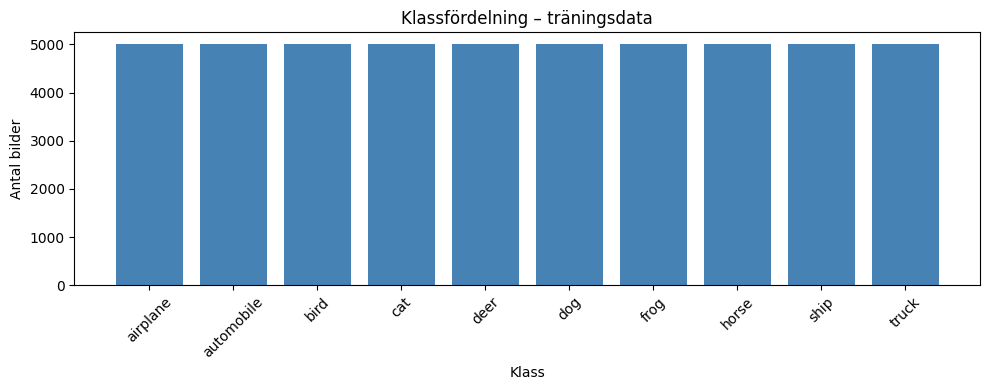

In [3]:
# Klassfördelning
# Visualisera klassfördelningen i träningsdata
fig, ax = plt.subplots(figsize=(10, 4))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_title('Klassfördelning – träningsdata')
ax.set_xlabel('Klass')
ax.set_ylabel('Antal bilder')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

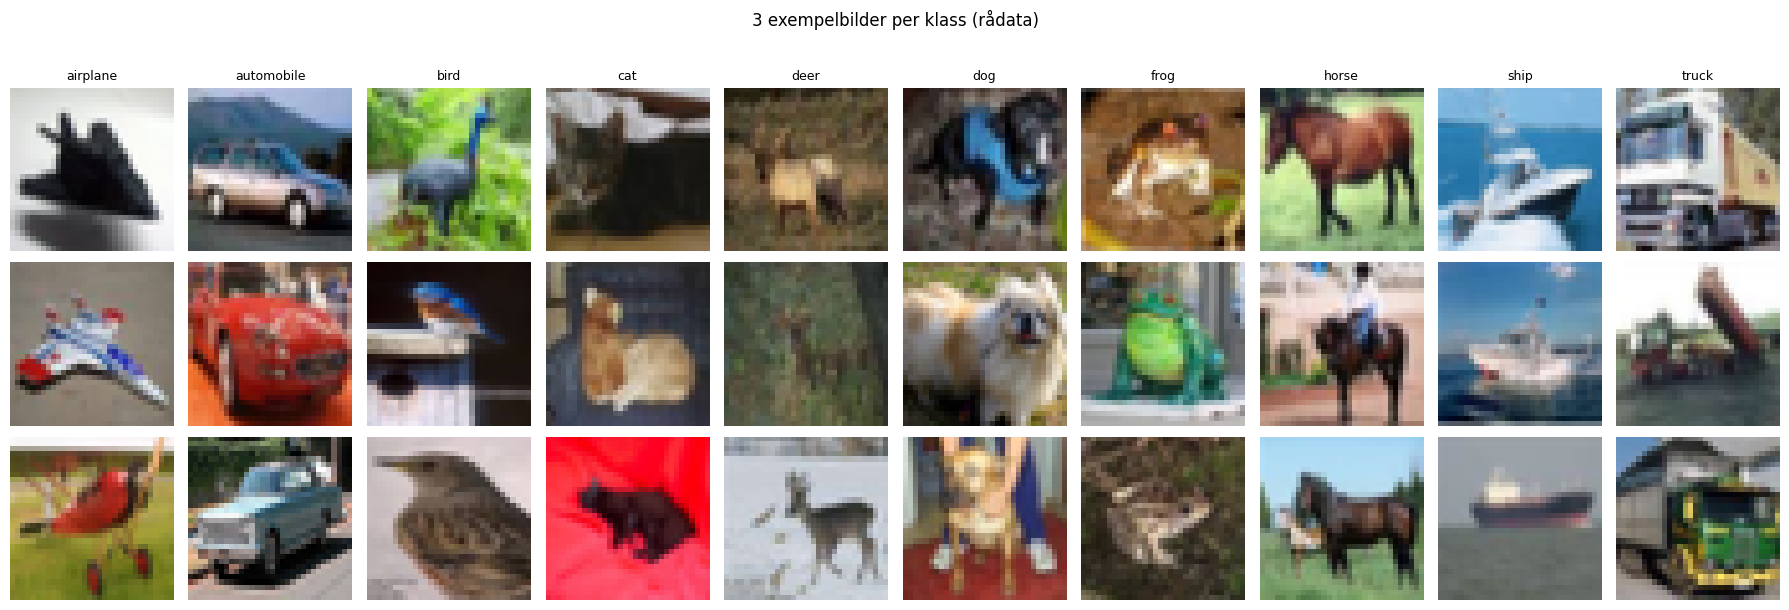

In [4]:
# Visa exempelbilder
# Visualisera 3 exempelbilder per klass
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for cls_idx in range(10):
    idxs = np.where(y_train == cls_idx)[0][:3]
    for row, img_idx in enumerate(idxs):
        axes[row, cls_idx].imshow(X_train[img_idx])
        axes[row, cls_idx].axis('off')
        if row == 0:
            axes[row, cls_idx].set_title(CLASS_NAMES[cls_idx], fontsize=9)
plt.suptitle('3 exempelbilder per klass (rådata)', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Förbehandling

In [5]:
# Normalisera pixlar till [0, 1]
# Detta förbättrar inlärningen och konvergensen av modellen.
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f"Pixelintervall (normaliserat): [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"Bildform: {X_train_norm.shape[1:]}  (höjd × bredd × kanaler)")

Pixelintervall (normaliserat): [0.0, 1.0]
Bildform: (32, 32, 3)  (höjd × bredd × kanaler)


---
## 4. Modell 1 – Baseline CNN

In [6]:
# Bygg en enkel CNN-modell
# Denna modell har tre konvolutionslager följt av maxpooling, och avslutas med två dense-lager.
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v1 = build_baseline_model()
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Träna modellen
# Vi använder EarlyStopping för att undvika överträning och återställa de bästa vikterna.
early_stop_v1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_v1 = model_v1.fit(
    X_train_norm, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_v1],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4568 - loss: 1.5025 - val_accuracy: 0.5750 - val_loss: 1.1866
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6228 - loss: 1.0725 - val_accuracy: 0.6540 - val_loss: 0.9822
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6858 - loss: 0.8970 - val_accuracy: 0.6880 - val_loss: 0.9027
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7284 - loss: 0.7772 - val_accuracy: 0.7000 - val_loss: 0.8847
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7612 - loss: 0.6867 - val_accuracy: 0.7015 - val_loss: 0.9015
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7902 - loss: 0.6078 - val_accuracy: 0.7050 - val_loss: 0.9159
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8120 - loss: 0.5416 - val_accuracy: 0.7074 - val_loss: 0.9355
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8303 - loss: 0.4847 - 

---
## 5. Utvärdering – Modell 1

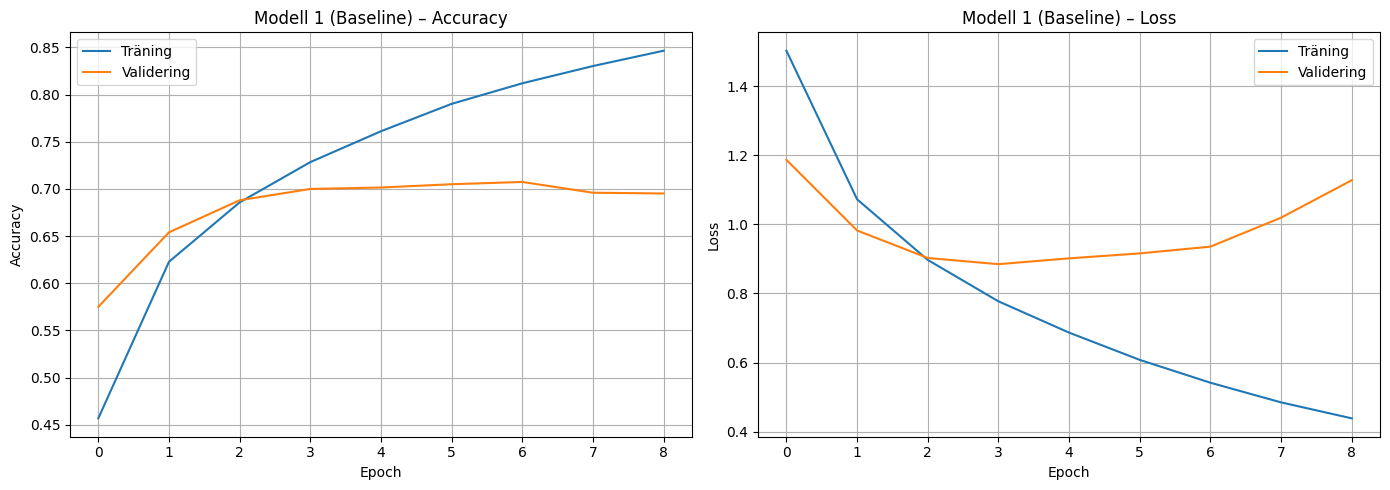

In [8]:
# Utvärdera modellen på testdata
# Vi rapporterar både förlust och noggrannhet på testsetet.
def plot_history(history, title='Träningshistorik'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Träning')
    ax1.plot(history.history['val_accuracy'], label='Validering')
    ax1.set_title(f'{title} – Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'],     label='Träning')
    ax2.plot(history.history['val_loss'], label='Validering')
    ax2.set_title(f'{title} – Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_v1, 'Modell 1 (Baseline)')

Modell 1 (Baseline) — Testaccuracy: 0.6968 | Testloss: 0.8926

Classification Report:
              precision    recall  f1-score   support

    airplane       0.75      0.77      0.76      1000
  automobile       0.78      0.85      0.81      1000
        bird       0.53      0.65      0.59      1000
         cat       0.49      0.54      0.52      1000
        deer       0.80      0.47      0.59      1000
         dog       0.62      0.56      0.59      1000
        frog       0.82      0.70      0.76      1000
       horse       0.68      0.83      0.75      1000
        ship       0.80      0.82      0.81      1000
       truck       0.79      0.77      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



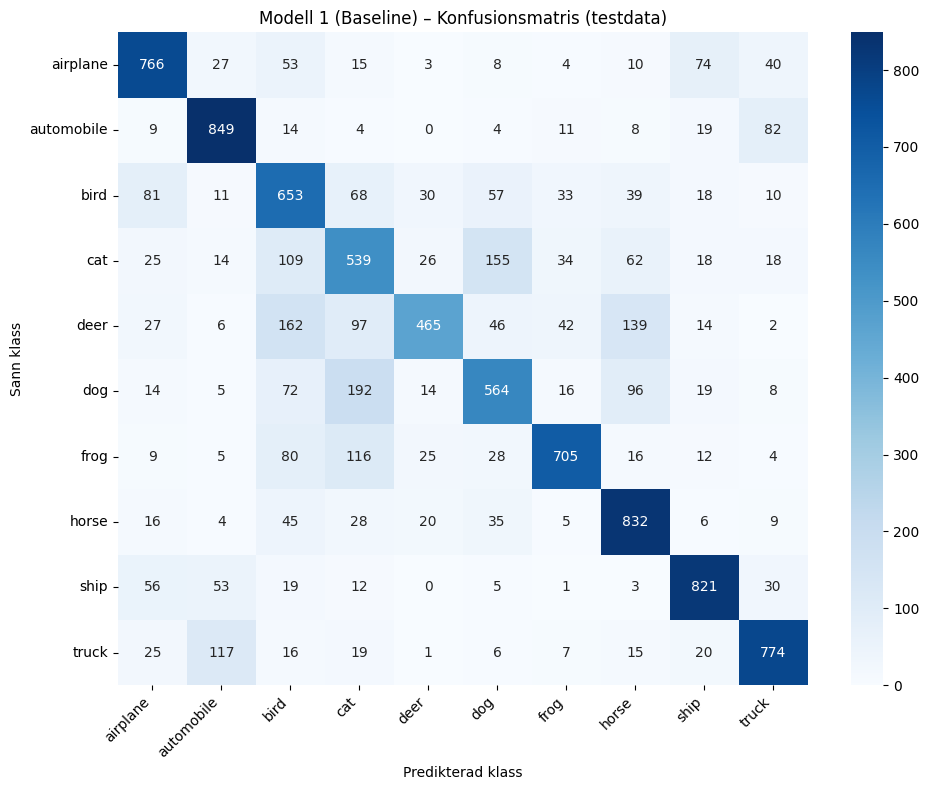

In [9]:
# Utvärdera modellen på testdata
# Vi rapporterar både förlust och noggrannhet på testsetet, samt visar en klassificeringsrapport och en konfusionsmatris.
def evaluate_model(model, X_test, y_test, model_name='Modell'):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} — Testaccuracy: {acc:.4f} | Testloss: {loss:.4f}\n")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{model_name} – Konfusionsmatris (testdata)')
    ax.set_xlabel('Predikterad klass')
    ax.set_ylabel('Sann klass')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

acc_v1, y_pred_v1 = evaluate_model(model_v1, X_test_norm, y_test, 'Modell 1 (Baseline)')

---
## 6. Analys - Behöver modellen justeras?

### Vad visar träningskurvorna?

När vi tittar på graferna ser vi ett tydligt mönster:

- **Träningsnoggrannheten** steg kontinuerligt och nådde ~87% vid epoch 11
- **Valideringsnoggrannheten** planade ut runt ~73% redan vid epoch 6–7, och började sedan sjunka
- **Valideringsförlusten** började stiga efter epoch 6, medan träningsförlusten fortsatte nedåt

Det här kallas **overfitting (överanpassning)** — modellen lär sig träningsdatan för bra, nästan utantill, och tappar förmågan att generalisera till bilder den aldrig sett. Gapet mellan 87% (träning) och 71% (test) på ~16 procentenheter bekräftar detta.

EarlyStopping stoppade träningen vid epoch 11 och återställde de bästa vikterna från epoch 6, vilket gav oss ett **testresultat på 71.17%**.

### Vad klarar modellen bra och dåligt?

| Klass | F1-score | Kommentar |
|-------|----------|-----------|
| automobile | 0.84 | Tydlig form, lätt att känna igen |
| ship | 0.80 | Stark kontrast mot bakgrund (hav) |
| truck | 0.80 | Lik bil men tydlig storlek |
| **cat** | **0.53** | Svårast — förväxlas med dog |
| **bird** | **0.59** | Förväxlas med airplane |
| **dog** | **0.61** | Förväxlas med cat |

Katt och hund är de svåraste klasserna — inte konstigt, de ser faktiskt lika ut. Samma sak med fågel och flygplan som båda kan ha liknande silhuetter mot himlen.

### Slutsats — behöver modellen justeras?

**Ja.** Overfitting är tydlig och testaccuracy på 71% har förbättringspotential. Vi går vidare med Modell 2 där vi introducerar:

- **Dropout** — stänger slumpmässigt av neuroner under träning för att tvinga modellen att lära sig mer robusta mönster
- **Data Augmentation** — skapar varianter av träningsbilderna (roterade, speglade etc.) så att modellen inte kan lära sig dem utantill
- **Dubbla Conv-lager per block** — ger nätverket mer kapacitet att fånga komplexa mönster

---
## 7. Modell 2 – Förbättrad CNN med Dropout och Data Augmentation

In [10]:
# Data augmentation för att minska overfitting
# Vi skapar en ImageDataGenerator som utför slumpmässiga transformationer på träningsbilderna under träning.
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train_norm)

# Validering augmenteras INTE – bara normaliseras
val_split = 0.2
val_size  = int(len(X_train_norm) * val_split)
X_val, y_val       = X_train_norm[:val_size],  y_train[:val_size]
X_tr2, y_tr2       = X_train_norm[val_size:],  y_train[val_size:]

train_gen = datagen.flow(X_tr2, y_tr2, batch_size=64, seed=SEED)
print(f"Träning: {X_tr2.shape[0]} bilder | Validering: {X_val.shape[0]} bilder")

Träning: 40000 bilder | Validering: 10000 bilder


In [11]:
def build_improved_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v2 = build_improved_model()
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [12]:
# Träna modellen
# Vi använder EarlyStopping och ReduceLROnPlateau för att optimera träningen och undvika överträning.
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_v2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

steps_per_epoch = len(X_tr2) // 64

history_v2 = model_v2.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_v2, reduce_lr_v2],
    verbose=1
)

model_v2.save('model_v2.keras')
print("Modell sparad till model_v2.keras")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 107ms/step - accuracy: 0.3878 - loss: 1.8058 - val_accuracy: 0.4939 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.5397 - loss: 1.2871 - val_accuracy: 0.6331 - val_loss: 1.0243 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.6019 - loss: 1.1200 - val_accuracy: 0.6034 - val_loss: 1.1480 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.6362 - loss: 1.0334 - val_accuracy: 0.6726 - val_loss: 0.9429 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.6614 - loss: 0.9624 - val_accuracy: 0.6155 - val_loss: 1.1985 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6788 - loss: 0.9151 - val_accuracy: 0.7227 - val_loss: 0.7918 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.69

KeyboardInterrupt: 

---
## 8. Utvärdering – Modell 2

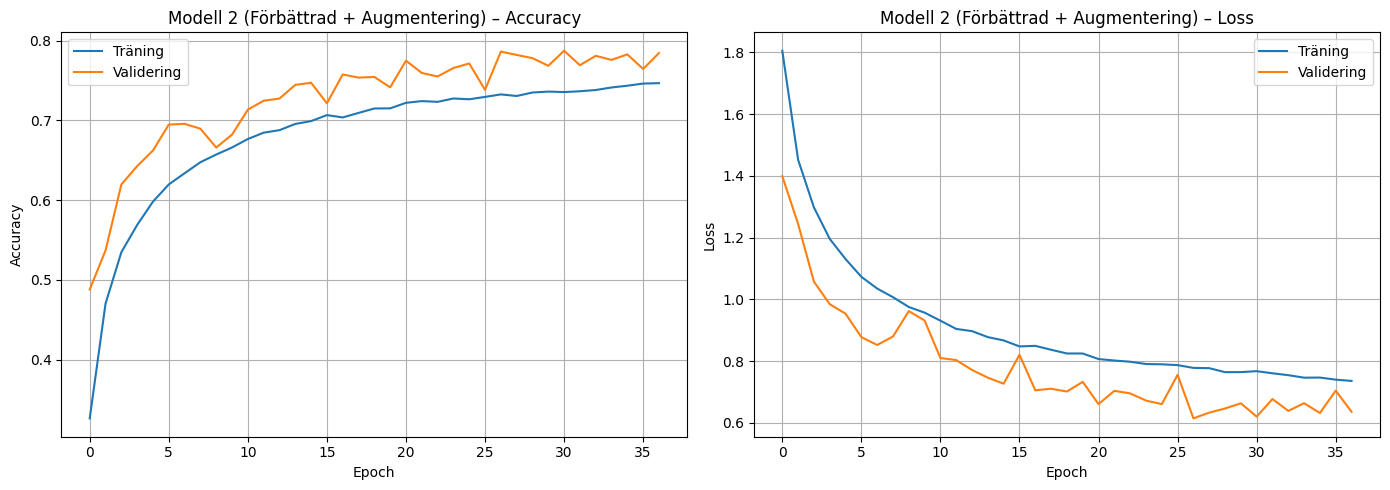

Modell 2 (Förbättrad) — Testaccuracy: 0.7821 | Testloss: 0.6349

Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.82      0.80      1000
  automobile       0.89      0.94      0.92      1000
        bird       0.81      0.58      0.68      1000
         cat       0.72      0.50      0.59      1000
        deer       0.82      0.68      0.74      1000
         dog       0.71      0.73      0.72      1000
        frog       0.63      0.94      0.75      1000
       horse       0.81      0.85      0.83      1000
        ship       0.89      0.86      0.87      1000
       truck       0.81      0.92      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.78     10000
weighted avg       0.79      0.78      0.78     10000



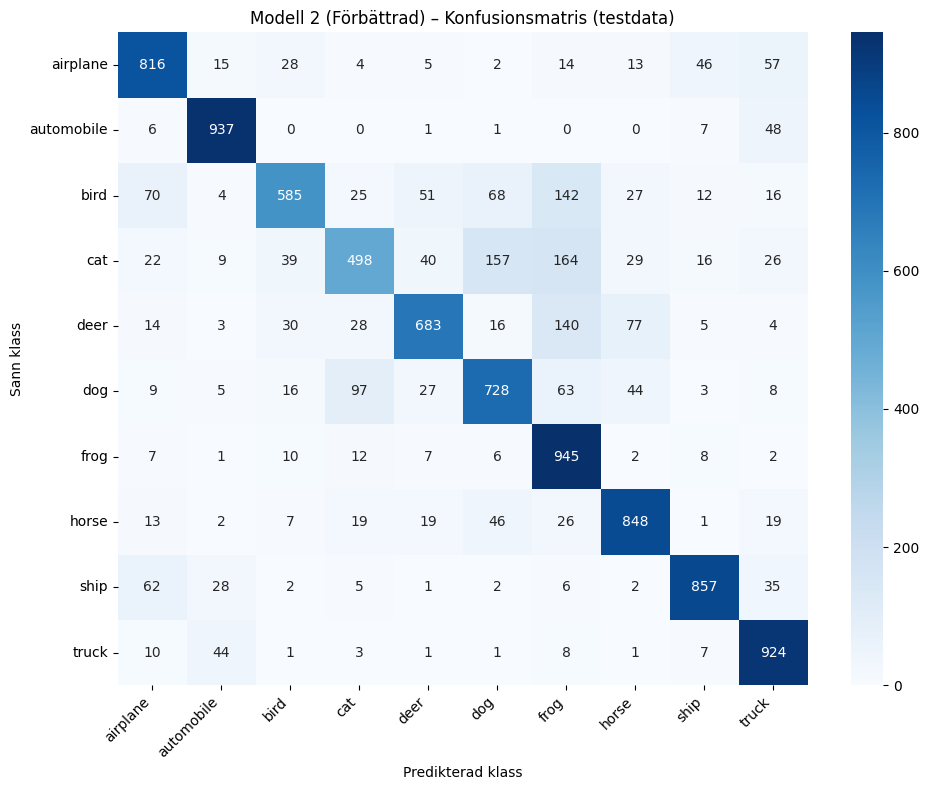

In [ ]:
# Utvärdera modellen på testdata
# Vi rapporterar både förlust och noggrannhet på testsetet, samt visar
plot_history(history_v2, 'Modell 2 (Förbättrad + Augmentering)')
acc_v2, y_pred_v2 = evaluate_model(model_v2, X_test_norm, y_test, 'Modell 2 (Förbättrad)')

---
## 9. Jämförelse av modeller

In [ ]:
# Sammanfattning av resultat
print("=" * 40)
print(f"{'Modell':<25} {'Test Accuracy':>15}")
print("-" * 40)
print(f"{'Modell 1 (Baseline)':<25} {acc_v1:>14.4f}")
print(f"{'Modell 2 (Förbättrad)':<25} {acc_v2:>14.4f}")
print("=" * 40)

Modell                      Test Accuracy
----------------------------------------
Modell 1 (Baseline)               0.7073
Modell 2 (Förbättrad)             0.7821


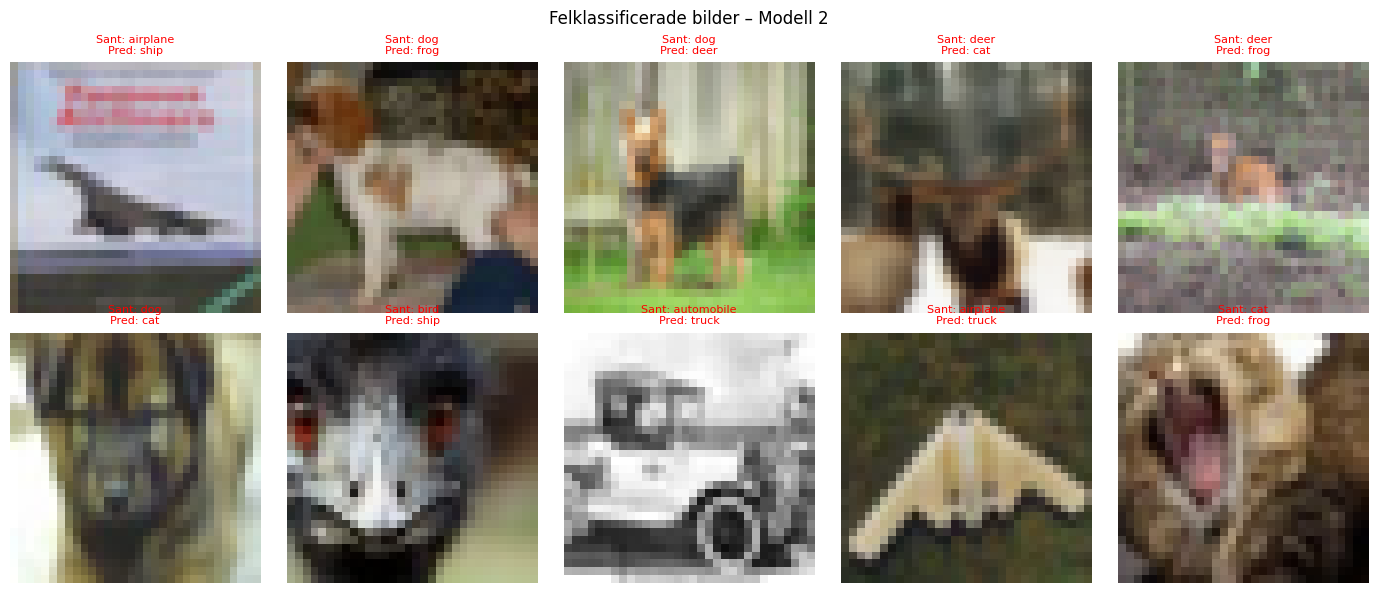

In [ ]:
# Visualisera felklassificerade bilder
# Vi visar några exempel på bilder som modellen klassificerade fel, tillsammans med deras sanna och predikterade klasser.
def show_misclassified(X_test, y_test, y_pred, class_names, n=10):
    wrong = np.where(y_pred != y_test)[0]
    sample = wrong[:n]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, idx in zip(axes.flat, sample):
        ax.imshow(X_test[idx])
        ax.set_title(f"Sant: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
                     fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle('Felklassificerade bilder – Modell 2', fontsize=12)
    plt.tight_layout()
    plt.show()

show_misclassified(X_test_norm, y_test, y_pred_v2, CLASS_NAMES)

---
## 10. Slutsatser och databerättelse

### Vad vi gjort
Vi tränade två CNN-modeller på CIFAR-10 — ett dataset med 60 000 RGB-bilder fördelade på 10 klasser. Målet var att bygga en modell som kan klassificera bilder korrekt, utvärdera dess svagheter och förbättra den utifrån vad vi observerade.

---

### Vad vi observerade

**Modell 1 (Baseline)** uppnådde **70.73% testaccuracy**.

Träningskurvorna visade tydlig overfitting — träningsnoggrannheten nådde 87% medan valideringsnoggrannheten planade ut och sjönk. Modellen lärde sig träningsdatan för bra och generaliserade dåligt till nya bilder. EarlyStopping stoppade träningen vid epoch 11 och räddade de bästa vikterna från epoch 6.

**Modell 2 (Förbättrad)** uppnådde **78.21% testaccuracy** — en förbättring på 7.5 procentenheter.

| | Modell 1 | Modell 2 |
|--|----------|----------|
| Testaccuracy | 70.73% | **78.21%** |
| Testloss | 0.8935 | **0.6349** |

Modell 2 tränade i 37 epoker innan EarlyStopping stoppade den. Till skillnad från Modell 1 var valideringsnoggrannheten konsekvent *högre* än träningsnoggrannheten — ett tydligt tecken på att Dropout fungerade som avsett.

---

### Svåraste klasser
Katt (cat) är den svåraste klassen i båda modellerna — 51% F1 i Modell 1 och 59% i Modell 2. Den förväxlas framförallt med hund, vilket är naturligt eftersom de har liknande kroppsform, päls och storlek. Fågel (bird) och flygplan (airplane) förväxlas också, troligtvis på grund av liknande silhuetter mot bakgrunden.

| Klass | Modell 1 F1 | Modell 2 F1 | Förändring |
|-------|-------------|-------------|------------|
| automobile | 0.84 | 0.92 | +8% |
| ship | 0.79 | 0.87 | +8% |
| truck | 0.79 | 0.86 | +7% |
| horse | 0.74 | 0.83 | +9% |
| dog | 0.61 | 0.72 | +11% |
| cat | 0.51 | 0.59 | +8% |

---

### Justeringar som gjordes (och varför)

- **Dropout** → stänger slumpmässigt av neuroner under träning, vilket tvingar modellen att lära sig mer robusta mönster istället för att memorera. Minskade gapet mellan tränings- och valideringsnoggrannhet markant.
- **Data Augmentation** → skapar varianter av träningsbilderna (rotation, spegling, zoom, förskjutning) så att modellen inte kan lära sig bilderna utantill. Ger effektivt ett större och mer varierat träningsset.
- **Dubbla Conv-lager per block** → ger nätverket mer kapacitet att fånga komplexa visuella mönster innan pooling krymper bilden.
- **Batch Normalization** → normaliserar aktiveringar efter varje konvolutionslager, vilket stabiliserar träningen och hjälper modellen konvergera snabbare och mer robust.
- **ReduceLROnPlateau** → sänker automatiskt inlärningshastigheten med faktor 0.5 när valideringsförlusten inte förbättras på 4 epoker, vilket gör att modellen kan "finjustera" sig i slutet av träningen utan att hoppa förbi ett bra minimum.
- **EarlyStopping** → förhindrade överträning i båda modellerna och återställde automatiskt de bästa vikterna.

---

### Möjliga framtida förbättringar

- **Transfer Learning (EfficientNetB0, ResNet50)** — använda ett nätverk som redan tränats på miljontals bilder och finjustera det för CIFAR-10. En människa som redan kan känna igen djur lär sig snabbare att skilja på katter och hundar — samma logik gäller här.
- **Mer Data Augmentation** — exempelvis färgjustering (ColorJitter) eller cutout (slumpmässigt blockera delar av bilden) för att göra modellen ännu mer robust mot variationer.